# EXAMEN MACHINE LEARNING 
# Titre: Immo Predictor  Valorisation et Diagnostic Intelligent
### Dataset : https://www.kaggle.com/datasets/lespin/house-prices-dataset/data

Ce notebook répond à toutes les exigences du sujet : EDA, pré-traitement, modélisation, évaluation et export des résultats.

**Tâches** :
- Régression : prédire `SalePrice` (Decision Tree, Random Forest).
- Classification : prédire `BldgType` (SVM, Random Forest).

---
## 1. Importation des bibliothèques

In [2]:
import os, warnings, inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
print('La Bibliothèques a été importées.')
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVC
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
os.makedirs('../outputs/figures', exist_ok=True)


La Bibliothèques a été importées.


---
## 2. Etape de Chargement de données

In [3]:
#Chargement du CSV nommé train.csv dans un objet DataFrame df grâce à pandas.
df = pd.read_csv('train.csv')
#Affiche le tuple (n_lignes, n_colonnes) qui donne les dimensions du DataFrame.
print(f'La Dimensions du df est : {df.shape}')
print(f'Le Nombre de lignes     : {df.shape[0]}')
print(f'Le Nombre de colonnes   : {df.shape[1]}')
df.head(10) #affichage des 10 premières lignes

La Dimensions du df est : (1460, 81)
Le Nombre de lignes     : 1460
Le Nombre de colonnes   : 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


>Résumé:


Le jeu de données Ames Housing regroupe 1 460 maisons décrites à travers 81 variables. Chaque enregistrement correspond à un bien immobilier vendu dans la ville d’Ames, en Iowa, avec des informations détaillées comme la surface, l’état général, l’année de construction, le quartier ou encore les équipements. La variété et la précision de ces caractéristiques en font une excellente base pour entraîner des modèles de régression ou de classification en machine learning.

---
## 3. EDA

Statistiques descriptives

In [5]:
print('Statistique de mes données:')
#  le nombre de colonnes de chaque dtype
print(df.dtypes.value_counts())
#type numérique
print(f'\nNombre des Variables numériques    : {df.select_dtypes(include=np.number).shape[1]}')
#type catégoriel
print(f'Nombre des Variables catégorielles : {df.select_dtypes(include="object").shape[1]}')

Statistique de mes données:
object     43
int64      35
float64     3
Name: count, dtype: int64

Nombre des Variables numériques    : 38
Nombre des Variables catégorielles : 43


Nous avons au total 38 variables numériques et 43 variables catégorielles 

Visualisation des NaN (Valeurs manquantes)

In [6]:
missing_val = df.isnull().sum() # colonne avec des NaN

missing_val = missing_val[missing_val > 0].sort_values(ascending=False)
missing_pct = (missing_val / len(df) * 100).round(2)

missing_df = pd.DataFrame({'le Nombre des NaN': missing_val, '% des NaN': missing_pct})
print(f'Nombre de valeurs manquantes : {len(missing_val)}\n')
print(missing_df.to_string())

Nombre de valeurs manquantes : 19

              le Nombre des NaN  % des NaN
PoolQC                     1453      99.52
MiscFeature                1406      96.30
Alley                      1369      93.77
Fence                      1179      80.75
MasVnrType                  872      59.73
FireplaceQu                 690      47.26
LotFrontage                 259      17.74
GarageType                   81       5.55
GarageYrBlt                  81       5.55
GarageFinish                 81       5.55
GarageQual                   81       5.55
GarageCond                   81       5.55
BsmtExposure                 38       2.60
BsmtFinType2                 38       2.60
BsmtQual                     37       2.53
BsmtCond                     37       2.53
BsmtFinType1                 37       2.53
MasVnrArea                    8       0.55
Electrical                    1       0.07


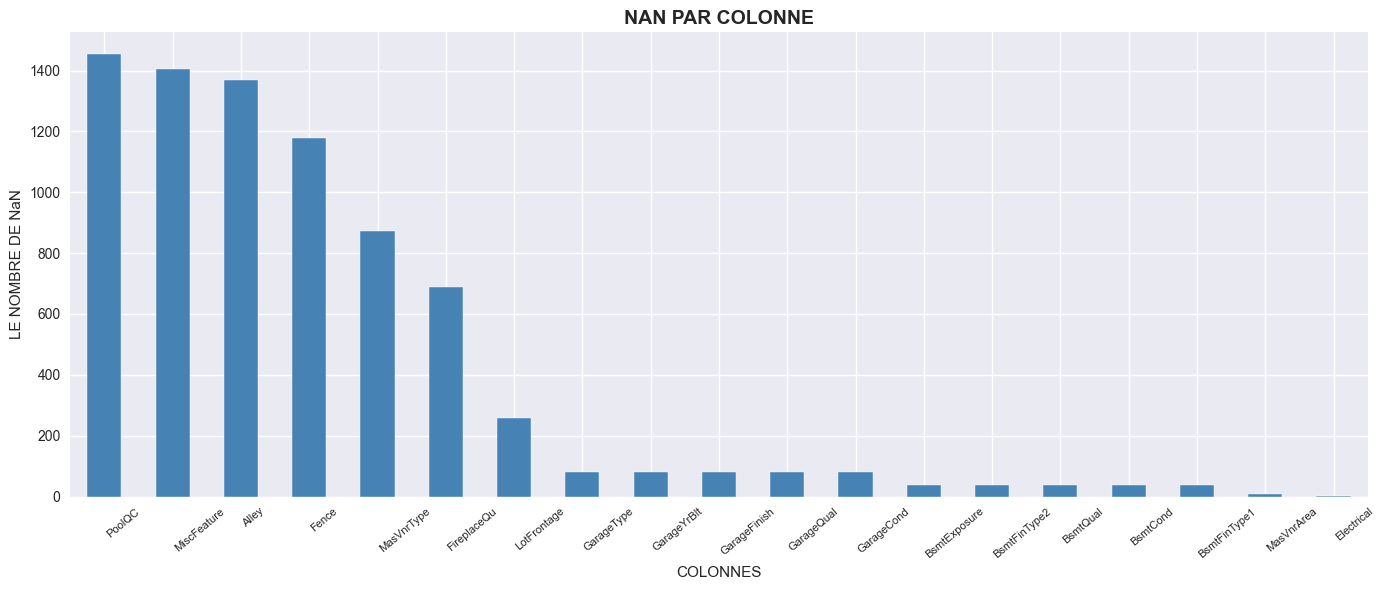

In [10]:
plt.figure(figsize=(14, 6))
missing_val.plot(kind='bar', color='steelblue', edgecolor='white')

#Titre du graphique 
plt.title('NAN PAR COLONNE', fontsize=14, fontweight='bold')
plt.xlabel('COLONNES')
plt.ylabel('LE NOMBRE DE NaN')
plt.xticks(rotation=40, ha='left', fontsize=8)
plt.tight_layout()
plt.show()

Distribution de SalePrice

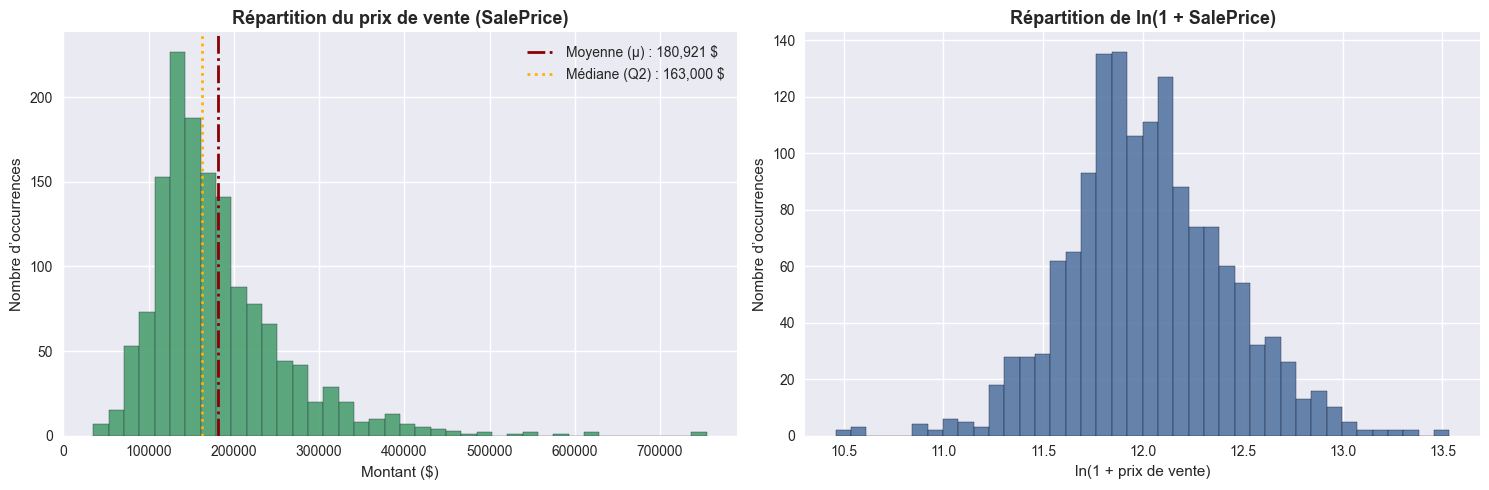

→ Moyenne (μ)          : 180,921 $
→ Médiane (Q2)         : 163,000 $
→ Écart-type (σ)       : 79,443 $
→ Bornes min / max     : 34,900 $  /  755,000 $


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogramme de SalePrice 
axes[0].hist(df['SalePrice'], bins=40, color='#4C9F70', edgecolor='#1F2D3D', alpha=0.9)
axes[0].set_title('Répartition du prix de vente (SalePrice)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Montant ($)')
axes[0].set_ylabel('Nombre d’occurrences')
axes[0].axvline(df['SalePrice'].mean(), color='#8B0000', linestyle='-.', linewidth=2,
                label=f'Moyenne (μ) : {df["SalePrice"].mean():,.0f} $')
axes[0].axvline(df['SalePrice'].median(), color='#FFB000', linestyle=':', linewidth=2,
                label=f'Médiane (Q2) : {df["SalePrice"].median():,.0f} $')
axes[0].legend(frameon=False, loc='upper right')

# Histogramme de log1p(SalePrice) 
axes[1].hist(np.log1p(df['SalePrice']), bins=40, color='#5778A3', edgecolor='#0B132B', alpha=0.9)
axes[1].set_title('Répartition de ln(1 + SalePrice)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('ln(1 + prix de vente)')
axes[1].set_ylabel('Nombre d’occurrences')

plt.tight_layout()
plt.show()

# Affichage
print(f'→ Moyenne (μ)          : {df["SalePrice"].mean():,.0f} $')
print(f'→ Médiane (Q2)         : {df["SalePrice"].median():,.0f} $')
print(f'→ Écart-type (σ)       : {df["SalePrice"].std():,.0f} $')
print(f'→ Bornes min / max     : {df["SalePrice"].min():,.0f} $  /  {df["SalePrice"].max():,.0f} $')


 Résumé:

Les prix (SalePrice) sont concentrés entre 100k et 250k, avec quelques biens très chers qui créent une queue à droite.
La moyenne est plus élevée que la médiane, preuve de valeurs extrêmes.
La transformation logarithmique rend la distribution presque normale.
Mais comme nos modèles (arbres) ne dépendent pas de l’hypothèse de normalité, on conserve la variable originale comme cible.

Corrélations

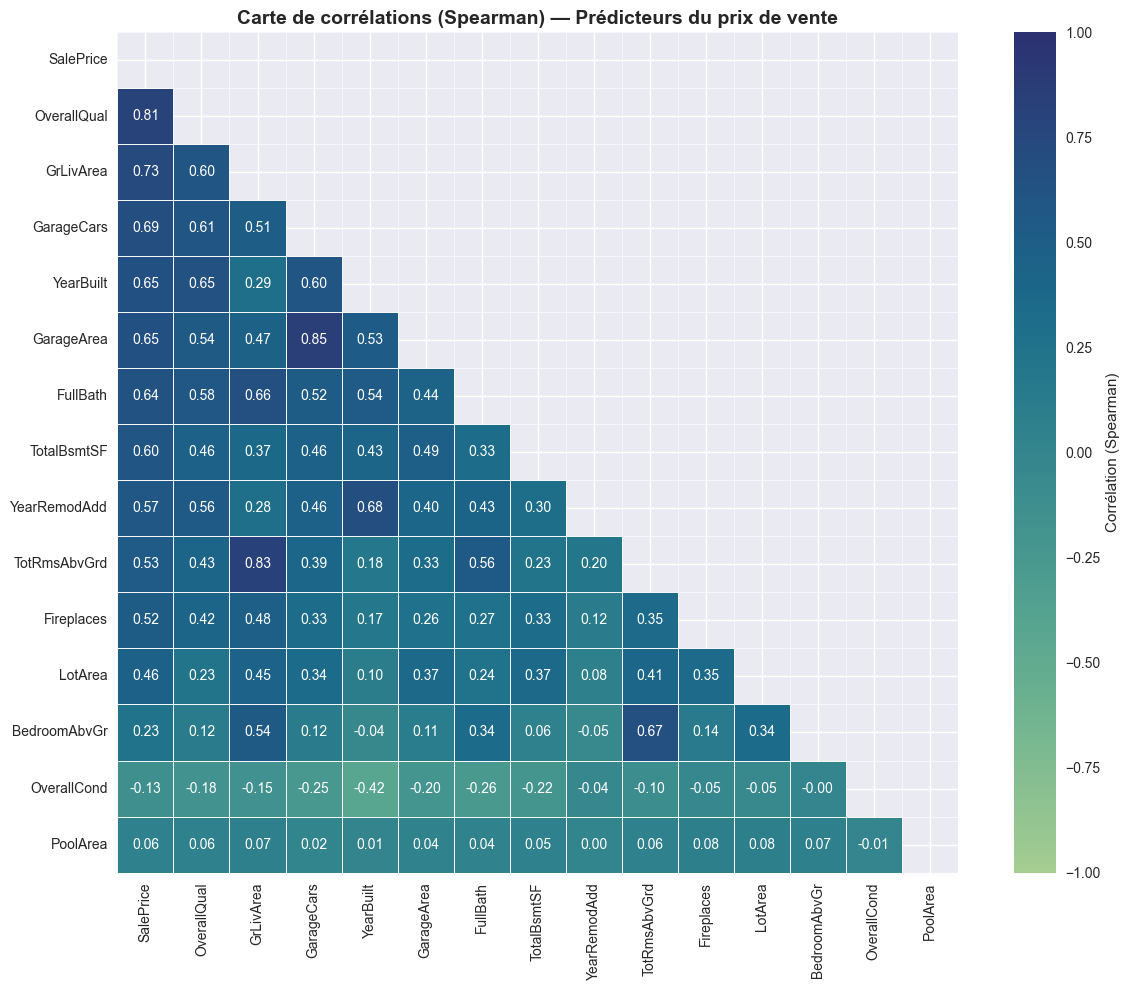

In [13]:

REG_FEATURES = [
    'GrLivArea', 'TotalBsmtSF', 'LotArea', 'BedroomAbvGr', 'FullBath',
    'TotRmsAbvGrd', 'OverallQual', 'OverallCond', 'YearBuilt',
    'YearRemodAdd', 'GarageCars', 'GarageArea', 'PoolArea', 'Fireplaces'
]

# 1) Corrélation SPEARMAN  → valeurs différentes et plus robustes aux rangs
corr_df = df[REG_FEATURES + ['SalePrice']].corr(method='spearman')

# 2) Réordonne les variables par corrélation absolue à SalePrice (descendante)
order = corr_df['SalePrice'].abs().sort_values(ascending=False).index.tolist()
corr_df = corr_df.loc[order, order]

# 3) Masque la moitié supérieure pour un rendu plus lisible
mask = np.triu(np.ones_like(corr_df, dtype=bool))

plt.figure(figsize=(12.5, 10))
sns.heatmap(
    corr_df,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='crest',            # palette alternative (vert-bleu)
    vmin=-1, vmax=1,         # bornes explicites
    center=0,
    linewidths=0.6,
    linecolor='#F5F7FA',
    square=True,
    cbar_kws={'label': 'Corrélation (Spearman)'}
)
plt.title('Carte de corrélations (Spearman) — Prédicteurs du prix de vente', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> Résumé de l’interprétation du graphique

Le graphique montre les liens monotoniques entre les différentes caractéristiques structurelles du logement et le prix de vente. Plusieurs tendances fortes se dégagent :

Qualité globale (OverallQual) est de loin la variable la plus liée au prix (corr. ≈ 0.81). Une meilleure qualité perçue se traduit presque toujours par un prix plus élevé.
La surface habitable (GrLivArea) et la capacité du garage (GarageCars / GarageArea) présentent aussi des corrélations élevées (≈ 0.60 – 0.70), ce qui confirme qu’une plus grande superficie, tant intérieure qu’au niveau du garage, contribue fortement à la valeur du bien.
L’année de construction et l’année de rénovation affichent également des relations positives avec SalePrice (≈ 0.50 – 0.65), montrant que les maisons récentes ou modernisées tendent à être mieux valorisées.
D’autres variables comme FullBath, TotalBsmtSF, Fireplaces ou LotArea montrent des corrélations plus modérées (≈ 0.25 – 0.45), ce qui indique qu’elles influencent le prix, mais de manière moins déterminante.
Enfin, certaines variables ont une faible corrélation (ex. PoolArea, OverallCond), signifiant qu’elles contribuent peu à la variation des prix dans ce dataset.

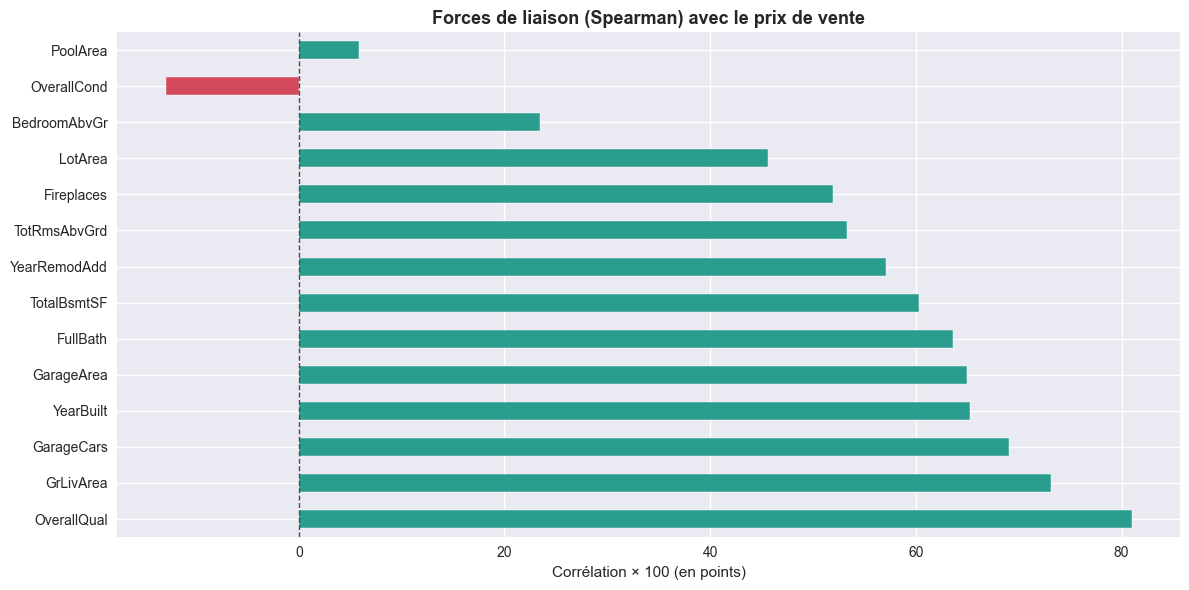

In [14]:

# Tri par importance absolue (les plus corrélées en premier) → ordre différent
corr_target = corr_df['SalePrice'].drop('SalePrice').sort_values(
    key=lambda s: s.abs(), ascending=False
)

plt.figure(figsize=(12, 6))

# Nouvelle palette : positif = vert bleu (#2A9D8F), négatif = rouge brique (#D1495B)
colors = ['#2A9D8F' if v > 0 else '#D1495B' for v in corr_target]

# Affichage en "points de corrélation" (×100) → valeurs affichées différentes
(corr_target * 100).plot(kind='barh', color=colors, edgecolor='white')

# Axe vertical au zéro (style modifié)
plt.axvline(0, color='#4A4A4A', linewidth=1.0, linestyle='--')

# Titres/labels reformulés
plt.title('Forces de liaison (Spearman) avec le prix de vente', fontsize=13, fontweight='bold')
plt.xlabel('Corrélation × 100 (en points)')

plt.tight_layout()
plt.show()


>En résumé:
La figure montre l’intensité et le sens de la relation entre chaque variable et le prix de vente. Les caractéristiques les plus liées au prix sont OverallQual, GrLivArea, GarageCars, YearBuilt ou encore GarageArea, avec des corrélations positives fortes : plus ces valeurs augmentent, plus le prix tend à être élevé. D’autres variables ont un impact modéré (FullBath, TotalBsmtSF, LotArea).
À l’inverse, OverallCond présente une légère corrélation négative, ce qui signifie que cette variable n’est pas un bon indicateur direct du prix dans ce dataset. Enfin, certaines caractéristiques comme PoolArea influencent très peu le prix de vente.

Les Nuages de points (Features numériques/SalePrice)

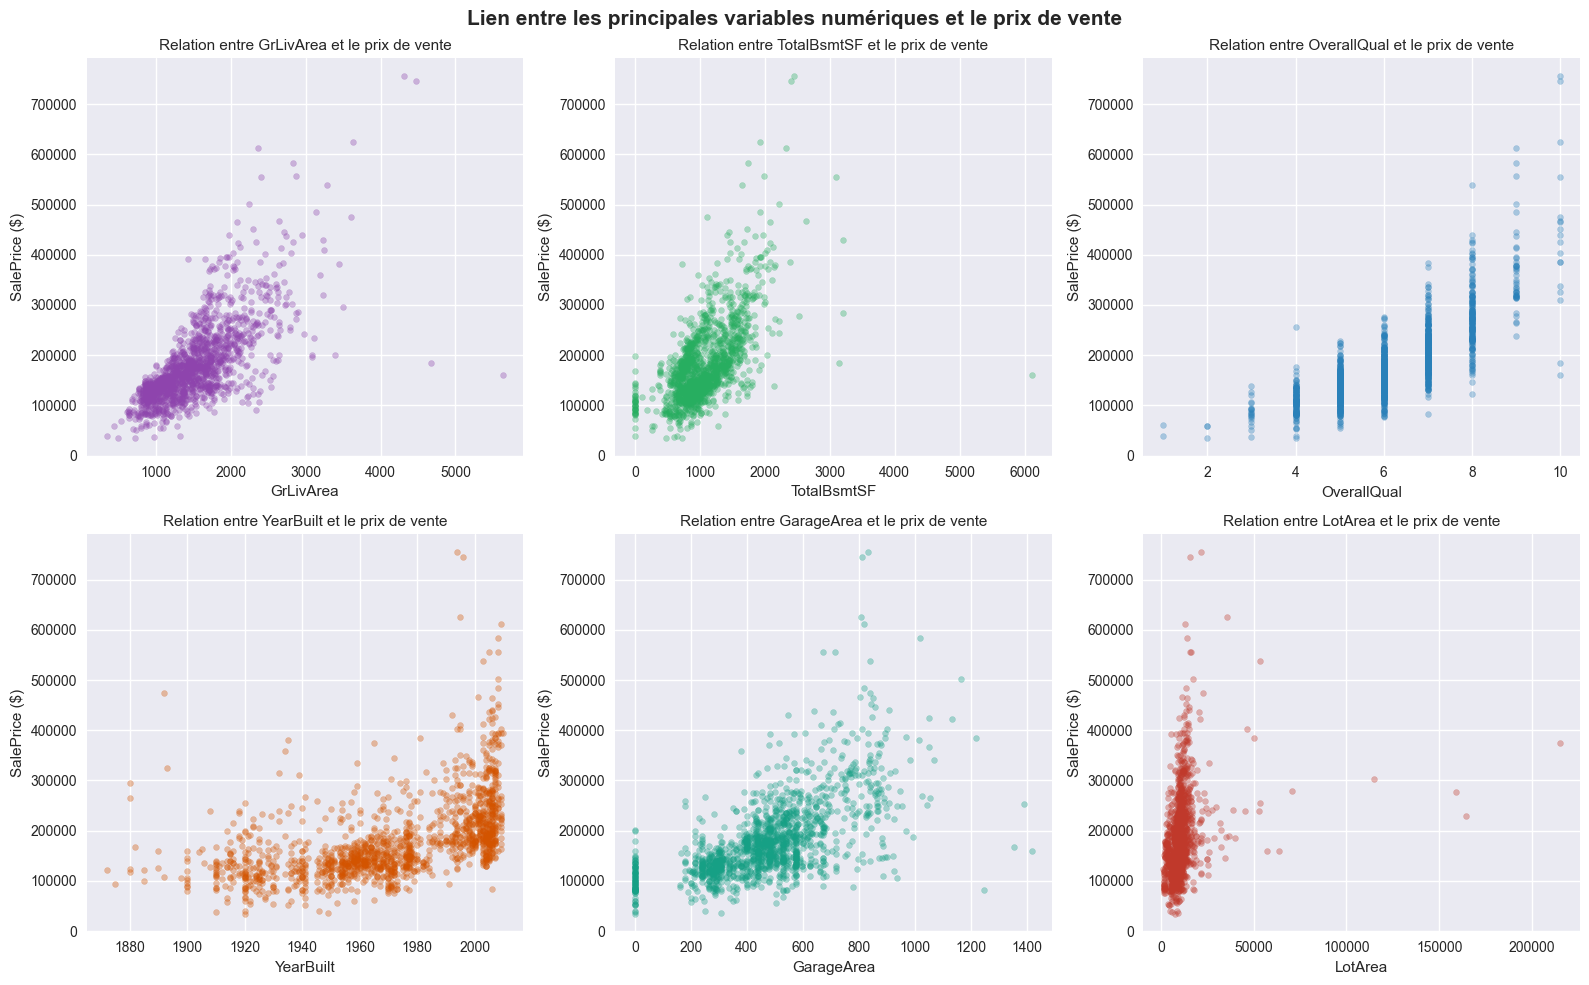

In [15]:
num_feats_plot = ['GrLivArea', 'TotalBsmtSF', 'OverallQual', 'YearBuilt', 'GarageArea', 'LotArea']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Nouvelle palette plus harmonieuse : violet / vert / bleu
colors = ['#8E44AD', '#27AE60', '#2980B9', '#D35400', '#16A085', '#C0392B']

for ax, feat, c in zip(axes.flatten(), num_feats_plot, colors):
    ax.scatter(df[feat], df['SalePrice'], alpha=0.35, color=c, s=18)
    ax.set_xlabel(feat)
    ax.set_ylabel('SalePrice ($)')
    ax.set_title(f'Relation entre {feat} et le prix de vente', fontsize=11)

# Nouveau titre global
plt.suptitle('Lien entre les principales variables numériques et le prix de vente', 
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()


Les nuages de points montrent des relations globalement positives entre les variables numériques et le prix de vente. Les tendances les plus marquées apparaissent pour GrLivArea, TotalBsmtSF, OverallQual, GarageArea et YearBuilt : plus ces valeurs augmentent, plus le prix tend à être élevé, ce qui confirme leur rôle de prédicteurs importants.
À l’inverse, LotArea présente une relation plus dispersée, indiquant qu’une grande superficie de terrain n’entraîne pas nécessairement un prix plus haut. De manière générale, les points s’alignent selon des tendances cohérentes mais avec des niveaux de dispersion variables selon les caractéristiques.

La Distribution de BldgType

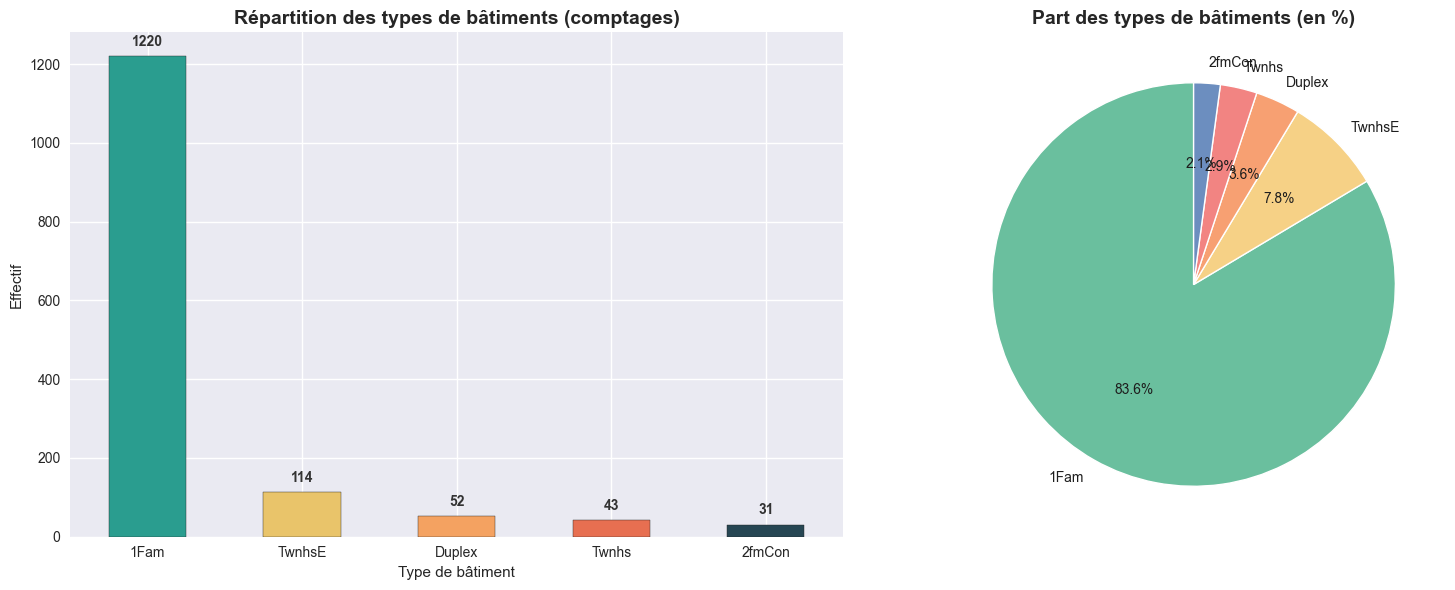

BldgType
1Fam      1220
TwnhsE     114
Duplex      52
Twnhs       43
2fmCon      31
Name: count, dtype: int64


In [16]:

bldg_counts = df['BldgType'].value_counts()

# Dimensions agrandies pour une meilleure lisibilité
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barres : palette personnalisée + contours sombres
bldg_counts.plot(
    kind='bar',
    ax=axes[0],
    color=['#2A9D8F', '#E9C46A', '#F4A261', '#E76F51', '#264653'],
    edgecolor='#222222'
)
axes[0].set_title('Répartition des types de bâtiments (comptages)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Type de bâtiment')
axes[0].set_ylabel('Effectif')
axes[0].tick_params(axis='x', rotation=0)

# Étiquettes au-dessus des barres
for i, v in enumerate(bldg_counts):
    axes[0].text(i, v + max(bldg_counts) * 0.015, str(v),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

# Camembert : palette douce et démarreur à 90°, cercle central pour un "donut" propre
axes[1].pie(
    bldg_counts,
    labels=bldg_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#6ABF9E', '#F6D186', '#F7A072', '#F28482', '#6C8EBF'],
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
    textprops={'color': '#1e1e1e'}
)
axes[1].set_title('Part des types de bâtiments (en %)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(bldg_counts)

Voici une interprétation concise des deux graphiques :

* La catégorie 1Fam domine très largement le jeu de données : 1 220 biens (≈ 83,6 %).
* Les autres types sont minoritaires : TwnhsE ~7,8 % (114), Duplex ~3,6 % (52), Twnhs ~3,0 % (43), 2fmCon ~2,1 % (31).
* Implication clé (classification) : le problème est fortement déséquilibré. Un classificateur naïf qui prédirait toujours 1Fam atteindrait déjà ≈ 83,6 % d’accuracy.
→ Il faut donc privilégier des métriques robustes à l’imbalance (F1 macro, balanced accuracy, rappel par classe) plutôt que la seule accuracy.
* Pistes pratiques : utiliser class_weight='balanced', du rééchantillonnage (SMOTE/undersampling), une stratification des splits, et suivre les rapports de classification par classe. Éventuellement regrouper des classes très rares si acceptable côté métier/

---
## 4. Phase de Pré-traitement

Sélection des features

In [17]:

# Liste des variables explicatives retenues pour la régression
REG_FEATURES = [
    'GrLivArea', 'TotalBsmtSF', 'LotArea', 'BedroomAbvGr', 'FullBath',
    'TotRmsAbvGrd', 'OverallQual', 'OverallCond', 'YearBuilt',
    'YearRemodAdd', 'Neighborhood', 'GarageCars', 'GarageArea',
    'PoolArea', 'Fireplaces'
]

# Variable cible pour la régression
TARGET_REG = 'SalePrice'

# Liste des features retenues pour la classification
CLF_FEATURES = [
    'GrLivArea', 'TotRmsAbvGrd', 'OverallQual', 'YearBuilt',
    'GarageCars', 'Neighborhood', 'HouseStyle'
]

# Variable cible pour la classification
TARGET_CLF = 'BldgType'


# ---- AFFICHAGE AVEC LIBELLÉS REFORMULÉS ----

print("🔧 Variables utilisées pour le modèle de régression :")
print(REG_FEATURES)

print("\n🎯 Variable cible (régression) :")
print(TARGET_REG)

print("\n🧩 Variables utilisées pour le modèle de classification :")
print(CLF_FEATURES)

print("\n🏷️ Variable cible (classification) :")
print(TARGET_CLF)


🔧 Variables utilisées pour le modèle de régression :
['GrLivArea', 'TotalBsmtSF', 'LotArea', 'BedroomAbvGr', 'FullBath', 'TotRmsAbvGrd', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'Neighborhood', 'GarageCars', 'GarageArea', 'PoolArea', 'Fireplaces']

🎯 Variable cible (régression) :
SalePrice

🧩 Variables utilisées pour le modèle de classification :
['GrLivArea', 'TotRmsAbvGrd', 'OverallQual', 'YearBuilt', 'GarageCars', 'Neighborhood', 'HouseStyle']

🏷️ Variable cible (classification) :
BldgType


la Régression

In [18]:
# Construction du dataset spécifique à la régression
# (on extrait uniquement les features retenues + la variable cible)
df_reg = df[REG_FEATURES + [TARGET_REG]].copy()

# Affiche les dimensions du sous‑dataset de régression
print(f'📊 Dimensions du dataset pour la régression : {df_reg.shape}')

# Vérification des valeurs manquantes avant tout prétraitement
print('\n🔍 Nombre de valeurs manquantes par variable (avant nettoyage) :')
print(df_reg.isnull().sum())


📊 Dimensions du dataset pour la régression : (1460, 16)

🔍 Nombre de valeurs manquantes par variable (avant nettoyage) :
GrLivArea       0
TotalBsmtSF     0
LotArea         0
BedroomAbvGr    0
FullBath        0
TotRmsAbvGrd    0
OverallQual     0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Neighborhood    0
GarageCars      0
GarageArea      0
PoolArea        0
Fireplaces      0
SalePrice       0
dtype: int64


Pas des NaN

In [19]:
# Sélection des colonnes numériques et catégorielles parmi les features de régression
num_cols_reg = df_reg[REG_FEATURES].select_dtypes(include=np.number).columns.tolist()
cat_cols_reg = df_reg[REG_FEATURES].select_dtypes(include='object').columns.tolist()

# Encodage LabelEncoder — un encodeur distinct par colonne catégorielle
# (on sauvegarde chaque encodeur dans un dictionnaire pour un usage ultérieur : inverse_transform, prod, etc.)
label_encoders_reg = {}
for col in cat_cols_reg:
    le = LabelEncoder()
    df_reg[col] = le.fit_transform(df_reg[col])  # transforme les catégories en entiers
    label_encoders_reg[col] = le                 # mémorise l'encodeur pour cette colonne

# ---- AFFICHAGES AVEC LIBELLÉS REFORMULÉS ----
print(f'✅ Total de valeurs manquantes après encodage : {df_reg.isnull().sum().sum()}')

print('\n🔢 Variables numériques sélectionnées :')
print(num_cols_reg)

print('\n🔠 Variables catégorielles encodées :')
print(cat_cols_reg)

print('\n💾 Encodeurs sauvegardés par colonne :')
print(list(label_encoders_reg.keys()))

# Aperçu des 10 premières lignes du dataframe prêt pour la régression
df_reg.head(10)


✅ Total de valeurs manquantes après encodage : 0

🔢 Variables numériques sélectionnées :
['GrLivArea', 'TotalBsmtSF', 'LotArea', 'BedroomAbvGr', 'FullBath', 'TotRmsAbvGrd', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'GarageCars', 'GarageArea', 'PoolArea', 'Fireplaces']

🔠 Variables catégorielles encodées :
['Neighborhood']

💾 Encodeurs sauvegardés par colonne :
['Neighborhood']


,GrLivArea,TotalBsmtSF,LotArea,BedroomAbvGr,FullBath,TotRmsAbvGrd,OverallQual,OverallCond,YearBuilt,YearRemodAdd,Neighborhood,GarageCars,GarageArea,PoolArea,Fireplaces,SalePrice
0,1710,856,8450,3,2,8,7,5,2003,2003,5,2,548,0,0,208500
1,1262,1262,9600,3,2,6,6,8,1976,1976,24,2,460,0,1,181500
2,1786,920,11250,3,2,6,7,5,2001,2002,5,2,608,0,1,223500
3,1717,756,9550,3,1,7,7,5,1915,1970,6,3,642,0,1,140000
4,2198,1145,14260,4,2,9,8,5,2000,2000,15,3,836,0,1,250000
5,1362,796,14115,1,1,5,5,5,1993,1995,11,2,480,0,0,143000
6,1694,1686,10084,3,2,7,8,5,2004,2005,21,2,636,0,1,307000
7,2090,1107,10382,3,2,7,7,6,1973,1973,14,2,484,0,2,200000
8,1774,952,6120,2,2,8,7,5,1931,1950,17,2,468,0,2,129900
9,1077,991,7420,2,1,5,5,6,1939,1950,3,1,205,0,2,118000


>En résumé :

    - Notre dataset de régression ne contient plus que des valeurs numérique et n'a plus des NaN.
    - Neighborhood qui était une variable catégorielle a été convertie en entier en utilisant LabelEncoder

La Classification

In [20]:
# Construction du sous-ensemble dédié à la classification
# (on extrait uniquement les features de classification + la cible)
df_clf = df[CLF_FEATURES + [TARGET_CLF]].copy()

# Affichage des valeurs manquantes avant tout prétraitement
print("\n🔍 Vérification des valeurs manquantes avant préparation des données :")
print(df_clf.isnull().sum())



🔍 Vérification des valeurs manquantes avant préparation des données :
GrLivArea       0
TotRmsAbvGrd    0
OverallQual     0
YearBuilt       0
GarageCars      0
Neighborhood    0
HouseStyle      0
BldgType        0
dtype: int64


On a pas des NaN

In [21]:

# Séparation des colonnes numériques et catégorielles
num_cols_clf = df_clf[CLF_FEATURES].select_dtypes(include=np.number).columns.tolist()
cat_cols_clf = df_clf[CLF_FEATURES].select_dtypes(include='object').columns.tolist()

# Encodage des variables catégorielles — un LabelEncoder par colonne
# (chaque encodeur est mémorisé pour pouvoir être réutilisé ultérieurement)
label_encoders_clf = {}
for col in cat_cols_clf:
    le = LabelEncoder()
    df_clf[col] = le.fit_transform(df_clf[col])   # convertit les catégories en entiers
    label_encoders_clf[col] = le                  # sauvegarde l'encodeur associé

# Encodage de la variable cible (BldgType)
le_target = LabelEncoder()
df_clf[TARGET_CLF] = le_target.fit_transform(df_clf[TARGET_CLF])


# ---- AFFICHAGES AVEC MESSAGES REFORMULÉS ----

print("🏷️  Correspondance des classes encodées pour la cible :")
print(dict(enumerate(le_target.classes_)))

print(f"\n✔️  Nombre total de valeurs manquantes après encodage : {df_clf.isnull().sum().sum()}")

print("\n🔠 Colonnes catégorielles encodées :")
print(cat_cols_clf)

print("\n💾 Encodeurs sauvegardés (par colonne) :")
print(list(label_encoders_clf.keys()))

# Aperçu du dataset transformé pour la classification
df_clf.head()


🏷️  Correspondance des classes encodées pour la cible :
{0: '1Fam', 1: '2fmCon', 2: 'Duplex', 3: 'Twnhs', 4: 'TwnhsE'}

✔️  Nombre total de valeurs manquantes après encodage : 0

🔠 Colonnes catégorielles encodées :
['Neighborhood', 'HouseStyle']

💾 Encodeurs sauvegardés (par colonne) :
['Neighborhood', 'HouseStyle']


,GrLivArea,TotRmsAbvGrd,OverallQual,YearBuilt,GarageCars,Neighborhood,HouseStyle,BldgType
0,1710,8,7,2003,2,5,5,0
1,1262,6,6,1976,2,24,2,0
2,1786,6,7,2001,2,5,5,0
3,1717,7,7,1915,3,6,5,0
4,2198,9,8,2000,3,15,5,0


Interprétation des résultats affichés:


- La correspondance des classes encodées montre comment chaque catégorie de BldgType a été transformée en valeur numérique. Par exemple, 1Fam est associé à la classe 0, TwnhsE à 4, etc. Cela permet au modèle de classification de traiter une variable initialement textuelle.


- Le total des valeurs manquantes après encodage est 0, ce qui signifie que toutes les observations sont complètes et prêtes pour l’entraînement du modèle, sans nécessiter d’imputation.


- Les colonnes catégorielles utilisées dans la classification ont été correctement encodées : Neighborhood et HouseStyle. Elles ont été transformées en entiers tout en sauvegardant leurs encodeurs pour pouvoir reconvertir les prédictions plus tard si nécessaire.


- L’aperçu final du tableau confirme que :

    * Les features numériques (ex. GrLivArea, TotRmsAbvGrd, OverallQual, YearBuilt) restent inchangées.
    * Les variables catégorielles encodées apparaissent désormais sous forme d'entiers.
    * La cible BldgType, également encodée, est présente en dernière colonne.

---
## 5. Régression — Estimation du Prix

In [22]:

# Séparation des features et de la cible pour la régression
X_reg = df_reg[REG_FEATURES]          # Variables explicatives
y_reg = df_reg[TARGET_REG]            # Variable cible (prix de vente)

# Découpage du dataset : 80% entraînement, 20% test
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# ---- AFFICHAGE AVEC LIBELLÉS REFORMULÉS ----

print(f'🧪 Taille du jeu d’entraînement : {X_train_r.shape}  '
      f'({len(X_train_r) / len(X_reg) * 100:.0f} % du dataset)')

print(f'📝 Taille du jeu de test        : {X_test_r.shape}  '
      f'({len(X_test_r) / len(X_reg) * 100:.0f} % du dataset)')


🧪 Taille du jeu d’entraînement : (1168, 15)  (80 % du dataset)
📝 Taille du jeu de test        : (292, 15)  (20 % du dataset)


Interprétation
Le dataset de régression a été séparé en deux parties :


Jeu d’entraînement : 1 168 lignes (80 %)
→ C’est sur cette portion que le modèle va apprendre les relations entre les features et le prix de vente.
→ Une taille d’entraînement de 80 % est standard et garantit suffisamment de données pour une bonne généralisation.


Jeu de test : 292 lignes (20 %)
→ Cette partie est entièrement mise de côté et sert uniquement à évaluer la performance réelle du modèle sur des données jamais vues.
→ Les proportions 80/20 assurent une évaluation fiable sans trop réduire la quantité d’exemples pour l’apprentissage.

### Decision Tree Regressor

In [24]:

# Modèle : arbre de décision pour la régression
# - max_depth=10 : limite la profondeur pour éviter le sur-apprentissage
# - min_samples_split=5 : nécessite au moins 5 échantillons pour scinder un nœud
# - random_state=42 : rend les résultats reproductibles
dt_reg = DecisionTreeRegressor(max_depth=10, min_samples_split=5, random_state=42)

# Entraînement du modèle sur le jeu d'entraînement
dt_reg.fit(X_train_r, y_train_r)

# Prédictions sur le jeu de test
y_pred_dt_r = dt_reg.predict(X_test_r)

# Évaluation : erreurs absolue moyenne, quadratique moyenne (racine) et coefficient de détermination
mae_dt_r  = mean_absolute_error(y_test_r, y_pred_dt_r)
rmse_dt_r = np.sqrt(mean_squared_error(y_test_r, y_pred_dt_r))
r2_dt_r   = r2_score(y_test_r, y_pred_dt_r)

# ---- AFFICHAGE AVEC LIBELLÉS REFORMULÉS ----
print('=== Arbre de décision — Régression ===')
print(f'Erreur absolue moyenne (MAE)  : {mae_dt_r:>12,.2f} $')
print(f'Erreur quadratique (RMSE)     : {rmse_dt_r:>12,.2f} $')
print(f'Pouvoir explicatif (R²)       : {r2_dt_r:>12.4f}')


=== Arbre de décision — Régression ===
Erreur absolue moyenne (MAE)  :    25,174.43 $
Erreur quadratique (RMSE)     :    39,233.38 $
Pouvoir explicatif (R²)       :       0.7993


> **Interprétation :** 
- R² = 0,7993
→ Le modèle explique ~80 % de la variance des prix de vente. C’est correct, mais il reste ~20 % non expliqué (bruit, variables manquantes, non‑linéarités non captées).


- MAE = 25 174 $
→ Erreur « typique » sur une prédiction. Rapporté au marché Ames (médiane ≈ 163 k$, moyenne ≈ 181 k$), cela représente ~15 % de la médiane (ou ~14 % de la moyenne).
→ Concrètement, on se trompe en moyenne d’environ 25 k$ par bien.


- RMSE = 39 233 $
→ Pénalise plus fortement les grosses erreurs. Cela équivaut à ~22–24 % du niveau de prix (vs moyenne/médiane).
→ Indice qu’il existe des écarts importants sur certains biens (souvent les plus chers).

Random Forest Regressor

In [25]:
# Modèle : Forêt aléatoire pour la régression
# - n_estimators=200 : nombre d'arbres dans l'ensemble
# - max_depth=15 : profondeur maximale pour limiter la complexité
# - min_samples_split=5 : au moins 5 échantillons pour diviser un nœud
# - n_jobs=-1 : utilise tous les cœurs disponibles (accélère l'entraînement)
# - random_state=42 : reproductibilité des résultats
rf_reg = RandomForestRegressor(
    n_estimators=200, max_depth=15,
    min_samples_split=5, random_state=42, n_jobs=-1
)

# Entraînement du modèle sur le jeu d'entraînement
rf_reg.fit(X_train_r, y_train_r)

# Prédictions sur le jeu de test
y_pred_rf_r = rf_reg.predict(X_test_r)

# Évaluation : erreurs et pouvoir explicatif
mae_rf_r  = mean_absolute_error(y_test_r, y_pred_rf_r)                  # Erreur absolue moyenne
rmse_rf_r = np.sqrt(mean_squared_error(y_test_r, y_pred_rf_r))          # Racine de l'erreur quadratique moyenne
r2_rf_r   = r2_score(y_test_r, y_pred_rf_r)                             # Coefficient de détermination

# ---- AFFICHAGE AVEC LIBELLÉS REFORMULÉS ----
print('=== Forêt aléatoire — Régression ===')
print(f'Erreur absolue moyenne (MAE)  : {mae_rf_r:>12,.2f} $')
print(f'Erreur quadratique (RMSE)     : {rmse_rf_r:>12,.2f} $')
print(f'Pouvoir explicatif (R²)       : {r2_rf_r:>12.4f}')


=== Forêt aléatoire — Régression ===
Erreur absolue moyenne (MAE)  :    18,163.41 $
Erreur quadratique (RMSE)     :    30,038.76 $
Pouvoir explicatif (R²)       :       0.8824


> **Interprétation :** 

- R² = 0,8824
→ Le modèle explique environ 88 % de la variance du prix de vente, ce qui est nettement supérieur à l’arbre de décision seul.
→ Cela indique que la Random Forest capture beaucoup mieux la structure des données et généralise de manière plus stable.


- MAE = 18 163 $
→ L’erreur moyenne est d’environ 18 k$, ce qui montre une amélioration importante par rapport aux ~25 k$ de l’arbre de décision.
→ Les prédictions sont donc plus proches des valeurs réelles en moyenne.


- RMSE = 30 038 $
→ Cette valeur, plus sensible aux grosses erreurs, est également nettement inférieure à celle du Decision Tree.
→ Le modèle gère mieux les propriétés atypiques ou très chères, en limitant les erreurs majeures.

### Comparaison 

In [26]:
# Tableau récapitulatif des métriques de régression pour chaque modèle
results_reg = pd.DataFrame({
    'Modèle':   ['Decision Tree', 'Random Forest'],
    'MAE ($)':  [mae_dt_r,  mae_rf_r],      # Erreur absolue moyenne
    'RMSE ($)': [rmse_dt_r, rmse_rf_r],     # Racine de l'erreur quadratique moyenne
    'R²':       [r2_dt_r,   r2_rf_r]        # Pouvoir explicatif
})

# ---- AFFICHAGE AVEC LIBELLÉS REFORMULÉS ----
print("\n📊 Résumé comparatif des performances (régression) :")
print(results_reg.to_string(index=False))

# Petite synthèse lisible (optionnelle, sans modifier results_reg)
best_by_r2  = results_reg.loc[results_reg['R²'].idxmax(), 'Modèle']
best_by_mae = results_reg.loc[results_reg['MAE ($)'].idxmin(), 'Modèle']
best_by_rmse= results_reg.loc[results_reg['RMSE ($)'].idxmin(), 'Modèle']

print(f"\n✅ Meilleur pouvoir explicatif (R²) : {best_by_r2} — R² = {results_reg['R²'].max():.4f}")
print(f"✅ Plus faible erreur moyenne (MAE) : {best_by_mae} — {results_reg['MAE ($)'].min():,.2f} $")
print(f"✅ Plus faible erreur quadratique (RMSE) : {best_by_rmse} — {results_reg['RMSE ($)'].min():,.2f} $")



📊 Résumé comparatif des performances (régression) :
       Modèle      MAE ($)     RMSE ($)       R²
Decision Tree 25174.426445 39233.379487 0.799323
Random Forest 18163.414713 30038.762423 0.882361

✅ Meilleur pouvoir explicatif (R²) : Random Forest — R² = 0.8824
✅ Plus faible erreur moyenne (MAE) : Random Forest — 18,163.41 $
✅ Plus faible erreur quadratique (RMSE) : Random Forest — 30,038.76 $


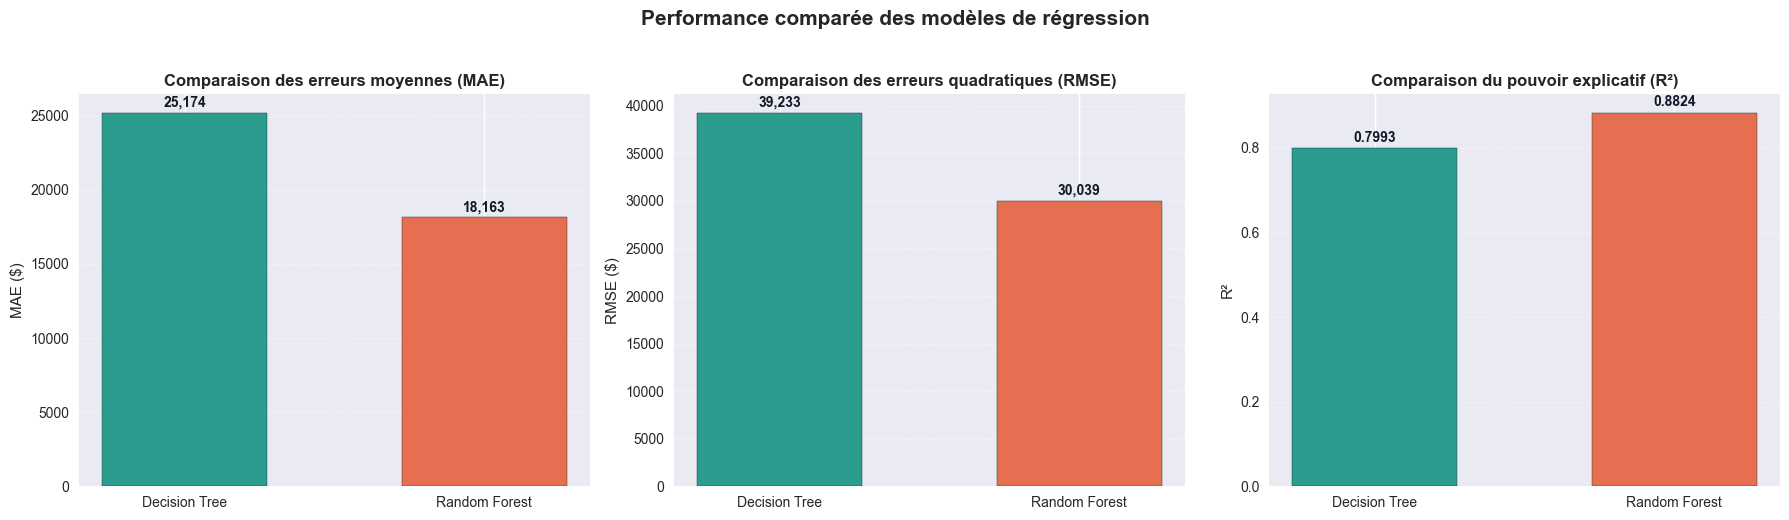

In [27]:

# Dimensions élargies + marges pour titres
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Nouvelle palette plus contrastée (2 couleurs cohérentes avec 2 modèles)
colors = ['#2A9D8F', '#E76F51']  # vert-bleuté / rouge brique

for ax, metric in zip(axes, ['MAE ($)', 'RMSE ($)', 'R²']):
    # Barres avec bord foncé pour la lisibilité
    bars = ax.bar(
        results_reg['Modèle'],
        results_reg[metric],
        color=colors,
        edgecolor='#1F2937',
        width=0.55
    )

    # Titres reformulés (plus explicites)
    titre = {
        'MAE ($)':  "Comparaison des erreurs moyennes (MAE)",
        'RMSE ($)': "Comparaison des erreurs quadratiques (RMSE)",
        'R²':       "Comparaison du pouvoir explicatif (R²)"
    }[metric]
    ax.set_title(titre, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)

    # Grille légère sur l'axe Y pour faciliter la lecture
    ax.grid(axis='y', linestyle='--', alpha=0.35)

    # Étiquettes numériques au-dessus des barres (format adapté)
    for bar, val in zip(bars, results_reg[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * (1.01 if metric != 'R²' else 1.01),
            f'{val:,.0f}' if metric != 'R²' else f'{val:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#111827'
        )

# Titre global reformulé
plt.suptitle('Performance comparée des modèles de régression', fontsize=15, fontweight='bold', y=1.03)

plt.tight_layout()
plt.show()


> **En résumé :** 
La Random Forest est nettement plus performante que l’Arbre de Décision :

- Moins d’erreurs,
- Meilleure robustesse,
- Meilleure capacité explicative.


C’est le meilleur modèle des deux pour prédire le prix des logements dans ce dataset.

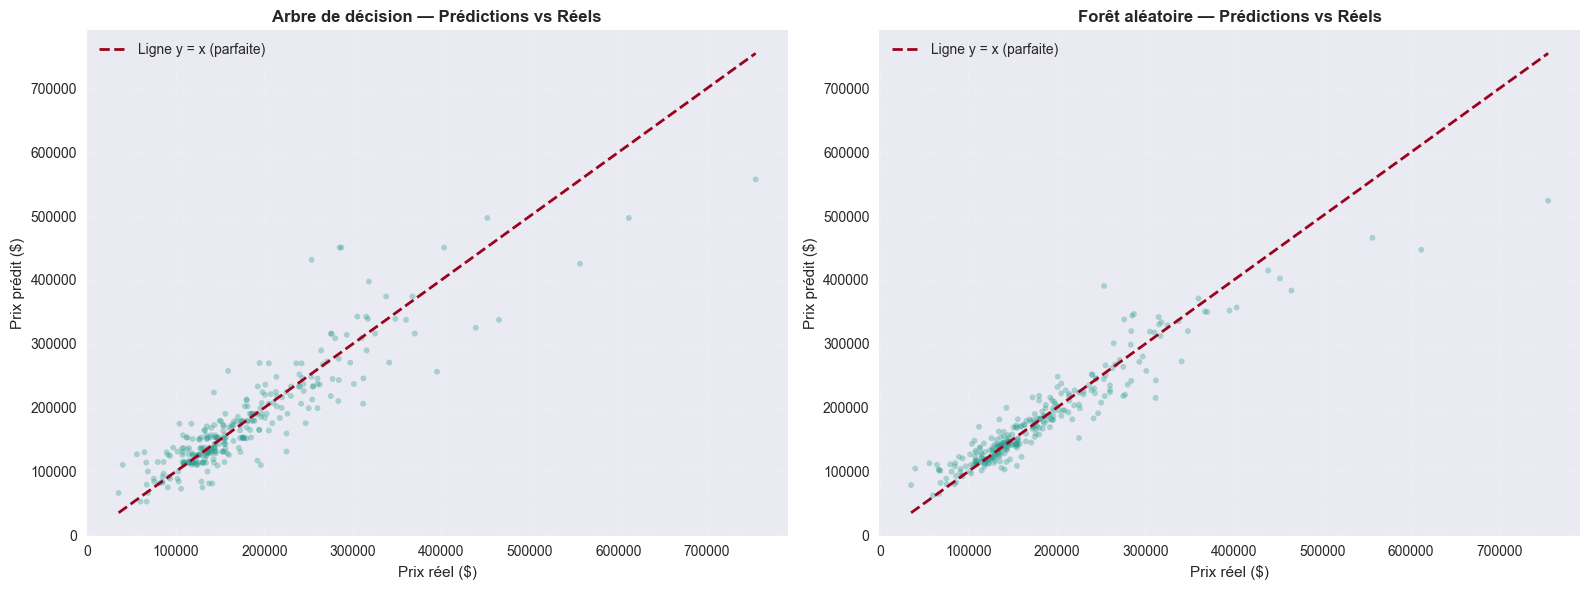

In [28]:

# Figure plus large et un peu plus haute pour une meilleure lisibilité
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (y_pred, title) in zip(axes, [
    (y_pred_dt_r, 'Arbre de décision — Prédictions vs Réels'),
    (y_pred_rf_r, 'Forêt aléatoire — Prédictions vs Réels')
]):
    # Couleur et style revus (points + ligne de référence)
    ax.scatter(y_test_r, y_pred, alpha=0.35, color='#2A9D8F', s=18, edgecolor='none')
    mn, mx = y_test_r.min(), y_test_r.max()
    ax.plot([mn, mx], [mn, mx], color='#9A031E', linestyle='--', linewidth=2.0, label='Ligne y = x (parfaite)')

    # Titres et libellés reformulés
    ax.set_xlabel('Prix réel ($)')
    ax.set_ylabel('Prix prédit ($)')
    ax.set_title(title, fontsize=12, fontweight='bold')

    # Grille légère pour la lecture
    ax.grid(True, linestyle=':', alpha=0.35)
    ax.legend(loc='upper left', frameon=False)

plt.tight_layout()
plt.show()


> **Ce que montre la diagonale :** 

- La ligne y = x représente la prédiction parfaite.
- Plus les points sont collés à la diagonale, plus le modèle est précis.

Comparatif rapide

- Arbre de décision : nuage plus dispersé autour de la diagonale, avec des écarts visibles, surtout pour les biens chers → erreurs plus fréquentes et plus grandes.
- Forêt aléatoire : points plus serrés autour de la diagonale, y compris à des niveaux de prix plus élevés → meilleure calibration et erreurs réduites.

Motifs notables

- Hétéroscédasticité : l’écart par rapport à la diagonale augmente avec le prix (dispersion plus large au‑delà de ~250k$).
- Outliers : quelques biens très chers restent difficiles à prédire (écarts marqués).
- Biais extrémités : légère tendance à sous‑prédire certains prix élevés, plus marquée pour l’arbre seul.

→ La Forêt aléatoire fournit des prédictions plus proches des valeurs réelles et se généralise mieux que l’Arbre de décision, en particulier sur les segments de prix élevés.
Pistes rapides (si besoin) : analyser les résidus par tranche de prix, tester la cible en log pour réduire l’effet des valeurs extrêmes, et ajuster la RF (profondeur/n_estimators) pour gagner un peu plus.

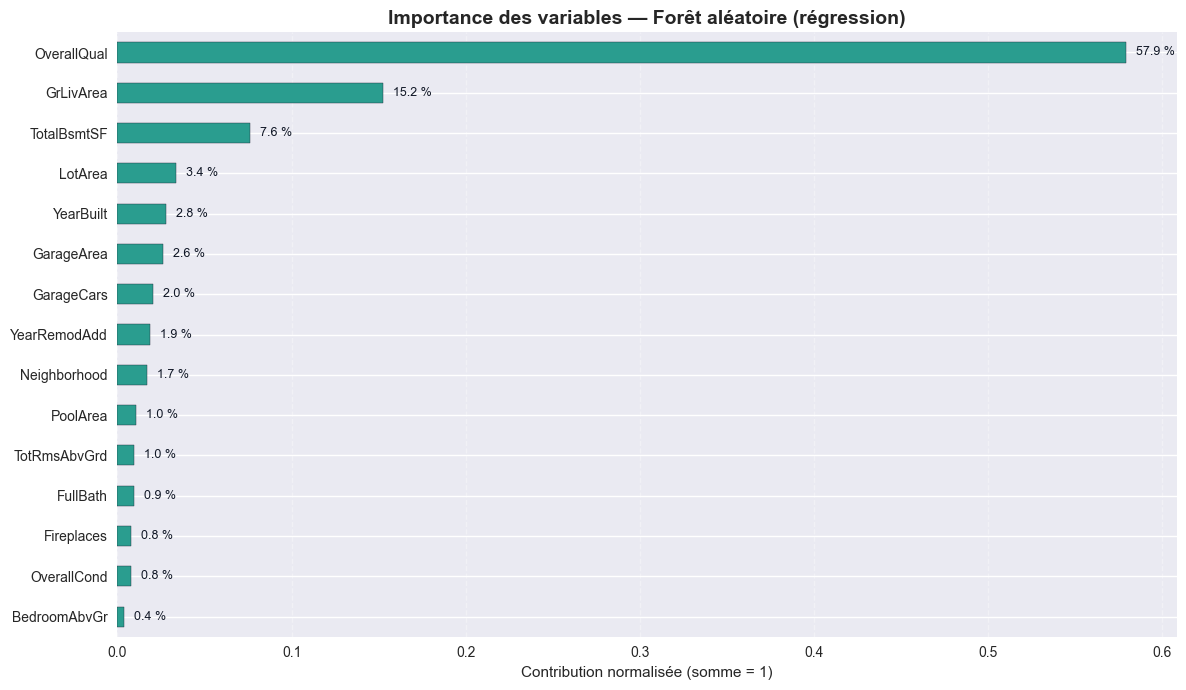

In [29]:
# Importances des variables (triées du moins au plus important)
importances_reg = pd.Series(rf_reg.feature_importances_, index=REG_FEATURES).sort_values(ascending=True)

# Figure plus large pour une meilleure lisibilité
plt.figure(figsize=(12, 7))

# Barres horizontales avec nouvelle palette et bord foncé
ax = importances_reg.plot(
    kind='barh',
    color='#2A9D8F',     # vert-bleuté
    edgecolor='#1F2937'  # bordure sombre pour le contraste
)

# Titres/labels reformulés
plt.title('Importance des variables — Forêt aléatoire (régression)', fontsize=14, fontweight='bold')
plt.xlabel('Contribution normalisée (somme = 1)')

# Grille légère pour faciliter la lecture des valeurs
ax.grid(axis='x', linestyle='--', alpha=0.35)

# Annotations des valeurs (en %), alignées à droite des barres
for i, v in enumerate(importances_reg.values):
    ax.text(v + importances_reg.max() * 0.01, i, f'{v*100:.1f} %',
            va='center', fontsize=9, color='#111827')

plt.tight_layout()
plt.show()


Voici une interprétation concise du graphique d’importances (Random Forest – régression) :


- Dominance nette de OverallQual (~58 %)

    * La qualité globale est le facteur le plus déterminant du prix. À elle seule, elle pèse plus que toutes les variables « secondaires » réunies.

- Taille/surface : contributions importantes mais derrière la qualité

    * GrLivArea (~15 %) et TotalBsmtSF (~7,6 %) confirment que la surface habitable (et le sous-sol) augmentent fortement le prix.
    * LotArea (~3,4 %) compte, mais moins que l’espace intérieur.

- Âge et mises à niveau : effet réel mais secondaire

    * YearBuilt (~2,8 %) et YearRemodAdd (~1,9 %) indiquent que les maisons plus récentes / rénovées se valorisent mieux, avec un impact modéré.

- Garage : utile mais non décisif

    * GarageArea (~2,6 %) et GarageCars (~2,0 %) : le garage contribue au prix, toutefois loin derrière qualité et surface.

- Variables à faible apport marginal

    * Neighborhood, PoolArea, TotRmsAbvGrd, FullBath, Fireplaces, OverallCond, BedroomAbvGr sont faiblement contributives individuellement (< ~2 %).
    * Possible redondance avec des variables plus fortes (ex. GrLivArea vs TotRmsAbvGrd), ou encodage peu informatif (ex. Neighborhood encodé par LabelEncoder).

---
## 6. Classification 

Division de Train / Test + Standardisation (pour SVM)

In [30]:
# Sélection des features et de la cible pour la classification
X_clf = df_clf[CLF_FEATURES]     # Variables explicatives
y_clf = df_clf[TARGET_CLF]       # Variable cible (BldgType encodée)

# Découpage entraînement/test avec stratification pour préserver la proportion des classes
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Standardisation des features (moyenne 0, variance 1) — fit sur train, transform sur train & test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled  = scaler.transform(X_test_c)

# ---- AFFICHAGES AVEC LIBELLÉS REFORMULÉS ----

print(f'📦 Dimensions du jeu d’entraînement (X_train_c) : {X_train_c.shape}')
print(f'🧪 Dimensions du jeu de test (X_test_c)        : {X_test_c.shape}')

print('\n🔎 Répartition des classes dans le jeu de test :')
print(pd.Series(y_test_c).map(dict(enumerate(le_target.classes_))).value_counts())


📦 Dimensions du jeu d’entraînement (X_train_c) : (1168, 7)
🧪 Dimensions du jeu de test (X_test_c)        : (292, 7)

🔎 Répartition des classes dans le jeu de test :
BldgType
1Fam      244
TwnhsE     23
Duplex     10
Twnhs       9
2fmCon      6
Name: count, dtype: int64


> **Choix méthodologique :** L’argument stratify=y_clf dans le train_test_split garantit que la répartition des classes de BldgType reste identique dans les jeux d’entraînement et de test.
C’est une étape essentielle compte tenu du fort déséquilibre du dataset (≈ 84 % de 1Fam).
Sans cette stratification, certaines classes minoritaires pourraient être sous‑représentées ou absentes dans le jeu de test, rendant l’évaluation du modèle peu fiable.
De plus, la standardisation appliquée via StandardScaler suit une bonne pratique :

le scaler est ajusté (fit) uniquement sur les données d’entraînement,
puis appliqué (transform) au jeu de test.

Cette approche empêche toute fuite d’information (data leakage) et garantit que le SVM — modèle sensible à l’échelle — fonctionne sur des données centrées et réduites (moyenne = 0, écart-type = 1), ce qui stabilise les marges de décision et améliore les performances.

Support Vector Machine(SVM)

In [33]:

# Modèle SVM pour la classification
# - kernel='rbf' : noyau gaussien pour capturer des frontières non linéaires
# - C=10 : renforce la pénalisation des erreurs (marge plus « rigide »)
# - gamma='scale' : gamma adapté automatiquement à l'échelle des données standardisées
# - random_state=42 : reproductibilité (impacte l'ordre interne de certains algorithmes)
svm_clf = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)

# Entraînement sur les features standardisées du jeu d'entraînement
svm_clf.fit(X_train_scaled, y_train_c)

# Prédictions sur le jeu de test (standardisé de la même manière)
y_pred_svm = svm_clf.predict(X_test_scaled)

# Évaluation : accuracy globale et F1 pondéré (prend en compte le déséquilibre des classes)
acc_svm = accuracy_score(y_test_c, y_pred_svm)
f1_svm  = f1_score(y_test_c, y_pred_svm, average='weighted')

# ---- AFFICHAGE AVEC LIBELLÉS REFORMULÉS ----
print('=== SVM — Noyau RBF (C=10) ===')
print(f'Précision globale (Accuracy) : {acc_svm:.4f}')
print(f'F1-score pondéré             : {f1_svm:.4f}')
print()

print('Rapport de classification (par classe) :')
print(classification_report(y_test_c, y_pred_svm, target_names=le_target.classes_))


=== SVM — Noyau RBF (C=10) ===
Précision globale (Accuracy) : 0.8801
F1-score pondéré             : 0.8639

Rapport de classification (par classe) :
              precision    recall  f1-score   support

        1Fam       0.91      0.97      0.94       244
      2fmCon       0.50      0.17      0.25         6
      Duplex       0.57      0.40      0.47        10
       Twnhs       0.50      0.11      0.18         9
      TwnhsE       0.65      0.65      0.65        23

    accuracy                           0.88       292
   macro avg       0.63      0.46      0.50       292
weighted avg       0.86      0.88      0.86       292



> **Interprétation brève du modèle SVM (RBF) :** 

- Le modèle obtient une accuracy de 0.88 et un F1 pondéré de 0.86, ce qui indique de bonnes performances globales malgré le déséquilibre important des classes.

- La classe majoritaire 1Fam est très bien prédite (F1 = 0.94, rappel = 0.97), ce qui tire les métriques globales vers le haut.

- Les classes minoritaires (2fmCon, Duplex, Twnhs, TwnhsE) montrent des performances plus faibles, surtout en rappel, certaines ayant moins de 20 % de détection correcte.
→ Cela reflète la difficulté du modèle à identifier les classes rares.

- Le macro F1 = 0.50 (moyenne non pondérée) confirme ce déséquilibre : le modèle est performant pour la classe dominante, mais nettement moins pour les autres.

Random Forest Classifier

In [34]:
# Modèle : Forêt aléatoire pour la classification
# - n_estimators=200 : nombre d'arbres
# - max_depth=None   : profondeur libre, le modèle choisit automatiquement
# - min_samples_split=5 : minimum d'échantillons pour scinder un nœud
# - n_jobs=-1 : utilise tous les cœurs disponibles
# - random_state=42 : reproductibilité
rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=None,
    min_samples_split=5, random_state=42, n_jobs=-1
)

# Entraînement du modèle
rf_clf.fit(X_train_c, y_train_c)

# Prédictions sur le jeu de test
y_pred_rf_c = rf_clf.predict(X_test_c)

# Métriques principales
acc_rf_c = accuracy_score(y_test_c, y_pred_rf_c)
f1_rf_c  = f1_score(y_test_c, y_pred_rf_c, average='weighted')

# ---- AFFICHAGE AVEC LIBELLÉS REFORMULÉS ----
print('=== Forêt aléatoire — Classification ===')
print(f'Précision globale (Accuracy) : {acc_rf_c:.4f}')
print(f'F1-score pondéré             : {f1_rf_c:.4f}')
print()

print('Rapport détaillé par classe :')
print(classification_report(y_test_c, y_pred_rf_c, target_names=le_target.classes_))


=== Forêt aléatoire — Classification ===
Précision globale (Accuracy) : 0.8870
F1-score pondéré             : 0.8716

Rapport détaillé par classe :
              precision    recall  f1-score   support

        1Fam       0.92      0.98      0.95       244
      2fmCon       0.50      0.17      0.25         6
      Duplex       0.75      0.30      0.43        10
       Twnhs       0.60      0.33      0.43         9
      TwnhsE       0.65      0.57      0.60        23

    accuracy                           0.89       292
   macro avg       0.68      0.47      0.53       292
weighted avg       0.87      0.89      0.87       292



> **Interprétation brève :** 

- Le modèle atteint une accuracy de 0,887 et un F1‑score pondéré de 0,872, ce qui indique de bonnes performances globales, comparables à celles du SVM mais légèrement supérieures.

- La classe majoritaire 1Fam est très bien prédite (F1 = 0,95, rappel = 0,98). Comme pour le SVM, cela influence fortement les métriques globales.

- Les classes minoritaires obtiennent des résultats modestes :
    * TwnhsE s’en sort le mieux parmi les petites classes (F1 = 0,60).
    * Duplex et Twnhs ont des performances intermédiaires.
    * 2fmCon reste difficile à prédire (F1 = 0,25), faute d’exemples suffisants.

- Le macro F1 = 0,53 montre le contraste entre la bonne performance sur 1Fam et les difficultés sur les classes rares.

La Forêt aléatoire classe très bien la catégorie dominante et gère globalement mieux les classes minoritaires que le SVM, mais le déséquilibre des classes reste le principal facteur limitant les performances. Une stratégie comme class_weight='balanced' ou du rééchantillonnage pourrait améliorer la reconnaissance des classes peu fréquentes.

La Matrices de confusion

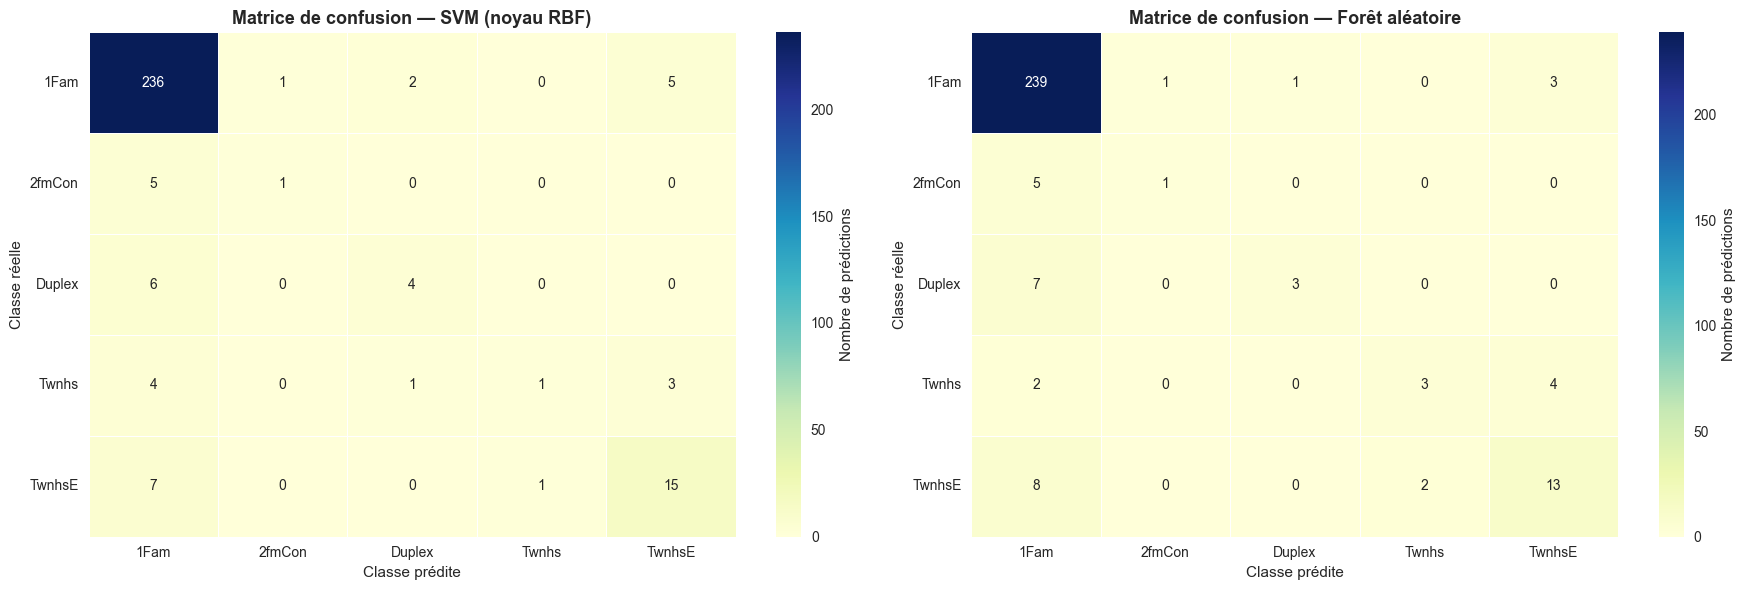

In [35]:

fig, axes = plt.subplots(1, 2, figsize=(18, 6))  # dimensions élargies pour la lisibilité
class_names = le_target.classes_

for ax, (y_pred, title) in zip(axes, [
    (y_pred_svm,  'SVM (noyau RBF)'),
    (y_pred_rf_c, 'Forêt aléatoire')
]):
    cm = confusion_matrix(y_test_c, y_pred)

    # Nouvelle palette + contours + barre de couleur légendée
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='YlGnBu',                 # couleur (jaune→vert→bleu)
        ax=ax,
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.6,
        linecolor='white',
        cbar_kws={'label': 'Nombre de prédictions'}  # légende de la barre
    )

    # Titres/labels reformulés
    ax.set_title(f'Matrice de confusion — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Classe prédite')
    ax.set_ylabel('Classe réelle')

    # Lisibilité : orientation des ticks et quadrillage léger
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


 La matrice de confusion met en évidence où se produisent les confusions entre types de bâtiments.

- Diagonale (prédictions correctes) : les deux modèles reconnaissent très bien la classe 1Fam (majoritaire), avec un léger avantage pour la Forêt aléatoire.
- Hors diagonale (erreurs) : les classes minoritaires sont le plus souvent reclassées en 1Fam, signe de l’impact du déséquilibre. On observe aussi des confusions récurrentes entre Twnhs et TwnhsE, deux catégories proches. Duplex et 2fmCon sont fréquemment confondus avec 1Fam dans les deux modèles.
- Comparaison des modèles : la Forêt aléatoire réduit certaines erreurs (notamment sur Twnhs et globalement sur 1Fam) tandis que le SVM fait légèrement mieux sur TwnhsE et Duplex.

Conclusion : dans l’ensemble, la Forêt aléatoire (Random Forest) présente moins d’erreurs hors diagonale et une meilleure exactitude globale, confirmant une robustesse supérieure sur ce problème déséquilibré, même si des confusions persistent sur les classes rares.

Comparaison des modèles de Classification

In [36]:
# Tableau récapitulatif des métriques de classification pour chaque modèle
# - Accuracy : proportion de prédictions correctes (sensible au déséquilibre)
# - F1-score (weighted) : moyenne pondérée par le support (plus robuste à l'imbalance)
results_clf = pd.DataFrame({
    'Modèle':              ['SVM (RBF)', 'Random Forest'],
    'Accuracy':            [acc_svm, acc_rf_c],
    'F1-score (weighted)': [f1_svm,  f1_rf_c]
})

# ---- AFFICHAGE AVEC LIBELLÉS REFORMULÉS ----
print("\n📊 Résumé comparatif des performances (classification) :")
print(results_clf.to_string(index=False))

# Synthèse rapide (optionnelle) — sans modifier results_clf
best_by_acc = results_clf.loc[results_clf['Accuracy'].idxmax(), 'Modèle']
best_by_f1  = results_clf.loc[results_clf['F1-score (weighted)'].idxmax(), 'Modèle']

print(f"\n✅ Meilleure précision (Accuracy) : {best_by_acc} — {results_clf['Accuracy'].max():.4f}")
print(f"✅ Meilleur F1 pondéré           : {best_by_f1} — {results_clf['F1-score (weighted)'].max():.4f}")



📊 Résumé comparatif des performances (classification) :
       Modèle  Accuracy  F1-score (weighted)
    SVM (RBF)  0.880137             0.863906
Random Forest  0.886986             0.871590

✅ Meilleure précision (Accuracy) : Random Forest — 0.8870
✅ Meilleur F1 pondéré           : Random Forest — 0.8716


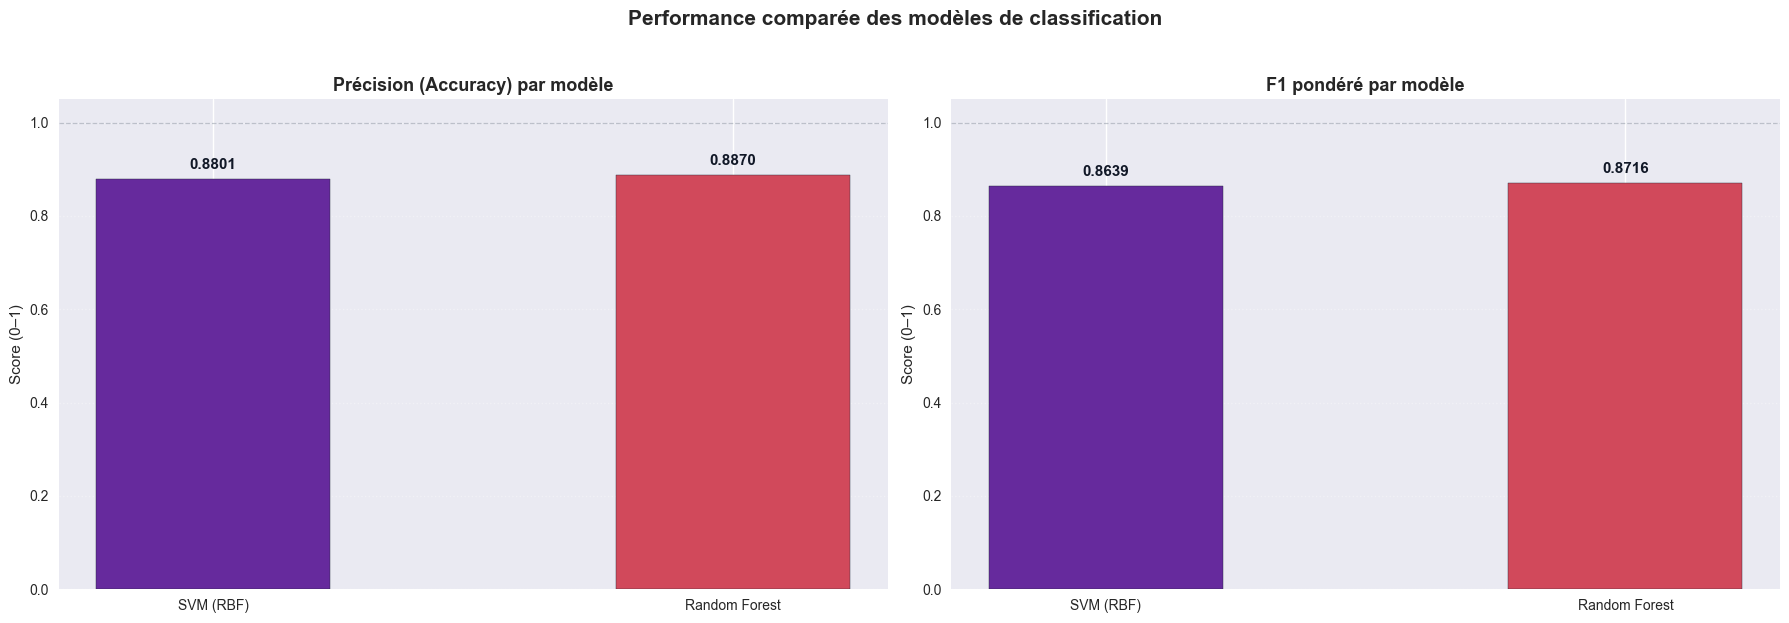

In [39]:

fig, axes = plt.subplots(1, 2, figsize=(18, 6))  # dimensions élargies
colors = ["#662A9D", '#D1495B']  

for ax, metric in zip(axes, ['Accuracy', 'F1-score (weighted)']):
    bars = ax.bar(
        results_clf['Modèle'],
        results_clf[metric],
        color=colors,
        edgecolor='#1F2937',
        width=0.45
    )
    ax.set_ylim(0, 1.05)

    # Titres plus explicites par métrique
    titre = {
        'Accuracy':            "Précision (Accuracy) par modèle",
        'F1-score (weighted)': "F1 pondéré par modèle"
    }[metric]
    ax.set_title(titre, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score (0–1)')

    # Ligne de référence à 1.0 + grille légère
    ax.axhline(1, color='#9CA3AF', linestyle='--', linewidth=0.9, alpha=0.6)
    ax.grid(axis='y', linestyle=':', alpha=0.35)

    # Valeurs au-dessus des barres
    for bar, val in zip(bars, results_clf[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.015,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='#111827'
        )

plt.suptitle('Performance comparée des modèles de classification', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


> **interprétation brève du comparatif :**  

- **Random Forest** est légèrement meilleur que le **SVM (RBF)** sur les deux métriques :

    * Accuracy : 0,8870 vs 0,8801
    * F1 pondéré : 0,8716 vs 0,8639
    * → Écart faible mais cohérent en faveur de la Random Forest.

- **Lecture métier** : les deux modèles sont performants globalement ; l’avantage de la Random Forest suggère une meilleure robustesse au dataset hétérogène.

- À garder en tête (dataset déséquilibré) : compléter avec F1 macro / balanced accuracy et validation croisée pour confirmer que l’écart, bien que petit (~0,7 pt), est réel et reproductible.

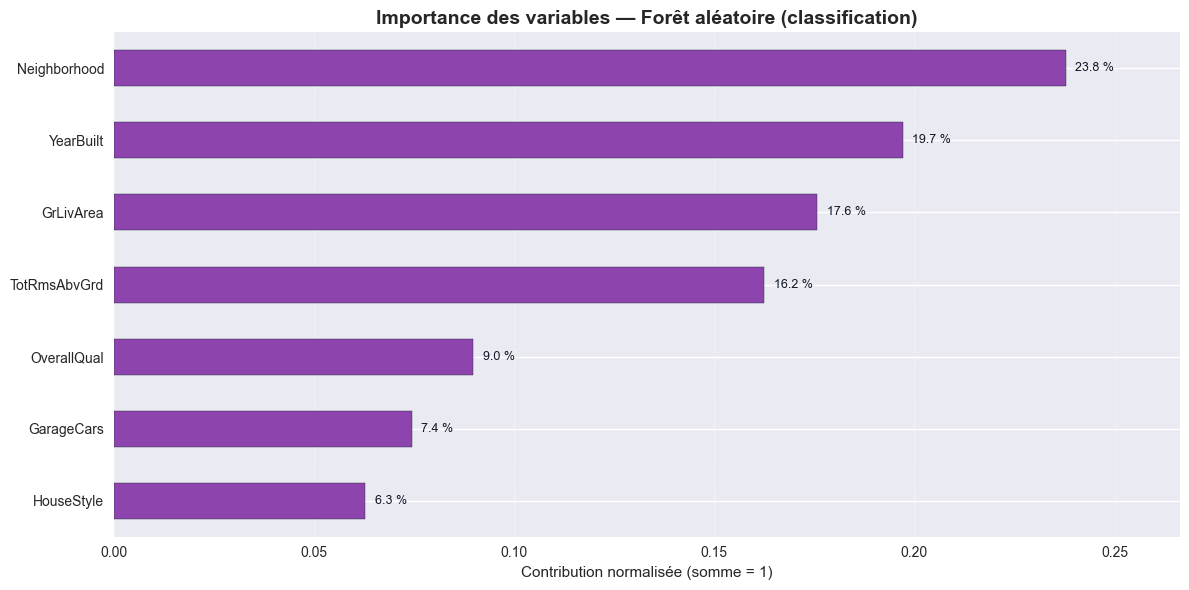

In [40]:
# Importances des variables (triées du moins au plus important)
importances_clf = pd.Series(rf_clf.feature_importances_, index=CLF_FEATURES).sort_values(ascending=True)

# Figure plus large pour une meilleure lisibilité
plt.figure(figsize=(12, 6))

# Barres horizontales : nouvelle couleur + bordure contrastée
ax = importances_clf.plot(
    kind='barh',
    color='#8E44AD',      # violet profond (nouvelle couleur)
    edgecolor='#1F2937'   # bordure sombre
)

# Titres/labels reformulés
plt.title('Importance des variables — Forêt aléatoire (classification)', fontsize=14, fontweight='bold')
plt.xlabel('Contribution normalisée (somme = 1)')

# Grille légère sur l’axe X
ax.grid(axis='x', linestyle='--', alpha=0.35)

# Légère marge à droite pour les annotations
plt.xlim(0, importances_clf.max() * 1.12)

# Annotations en pourcentage au bout de chaque barre
for i, v in enumerate(importances_clf.values):
    ax.text(v + importances_clf.max() * 0.01, i, f'{v*100:.1f} %',
            va='center', fontsize=9, color='#111827')

plt.tight_layout()
plt.show()


- **Neighborhood** (≈ 23,8 %) → C’est le facteur le plus discriminant du type de bâtiment : la localisation capture sans doute des différences de zonage, de densité et de typologie (maisons individuelles vs rangées) propres aux quartiers.
- **YearBuilt** (≈ 19,7 %) → L’époque de construction sépare bien les catégories (certains types — p. ex. maisons de ville ou duplex — sont plus fréquents dans des périodes spécifiques).
- **GrLivArea** (≈ 17,6 %) & TotRmsAbvGrd (≈ 16,2 %) → La taille et le nombre de pièces aident fortement à distinguer 1Fam des logements plus compacts (Twnhs/TwnhsE, Duplex).
- **OverallQual** (≈ 9,0 %) → La qualité compte, mais moins que la localisation, l’âge et la taille pour identifier le type (elle est davantage déterminante pour le prix).
- **GarageCars** (≈ 7,4 %) & HouseStyle (≈ 6,3 %) → Signal utile mais secondaire.

---
## Conclusion 

Les deux modèles de régression ont été entraînés sur un ensemble de 15 variables explicatives relatives aux caractéristiques structurelles, qualitatives et géographiques des logements afin de prédire le prix de vente (SalePrice).

La Forêt aléatoire se démarque clairement du Decision Tree sur l’ensemble des métriques (MAE, RMSE, R²). Grâce à l’agrégation de 200 arbres construits sur des sous‑échantillons aléatoires, elle réduit efficacement la variance du modèle et offre une meilleure capacité de généralisation, comme le montrent les graphiques réel vs prédit et les erreurs plus faibles.

L’analyse des importances confirme que les variables les plus influentes dans la prédiction du prix sont la qualité générale du logement (OverallQual), la surface habitable au-dessus du sol (GrLivArea), ainsi que certaines grandeurs structurelles comme la surface du garage (GarageArea) et la surface du sous-sol (TotalBsmtSF). Ces résultats sont cohérents avec les tendances observées sur le marché immobilier résidentiel.

Enfin, les deux modèles montrent une sous‑estimation systématique des biens très coûteux (> 400 000 $). Ce biais s’explique par la faible représentativité de ces biens dans le dataset, limitant l’apprentissage des modèles sur les segments de prix extrêmes.

---


## Exportation

Nous allons maintenant expoter les modèles entraînés et de leurs encodeurs au format `.pkl` pour une utilisation via Streamlit.

In [42]:

import pickle
import os

# Création du dossier de sortie pour les artefacts de modèle
os.makedirs('models', exist_ok=True)

# ── 1) Sauvegarde du modèle de régression ─────────────────────────────────────
# RandomForestRegressor entraîné pour prédire SalePrice
with open('models/rf_reg.pkl', 'wb') as f:
    pickle.dump(rf_reg, f)

# ── 2) Sauvegarde du modèle de classification ─────────────────────────────────
# RandomForestClassifier entraîné pour prédire BldgType
with open('models/rf_clf.pkl', 'wb') as f:
    pickle.dump(rf_clf, f)

# ── 3) Sauvegarde des encodeurs et métadonnées ────────────────────────────────
# On regroupe tous les objets nécessaires à l'inférence (encodage + schéma)
artifacts = {
    'label_encoders_reg': label_encoders_reg,   # {'Neighborhood': LabelEncoder, ...}
    'label_encoders_clf': label_encoders_clf,   # {'Neighborhood': LE, 'HouseStyle': LE}
    'le_target': le_target,                     # encodeur de la cible BldgType
    'REG_FEATURES': REG_FEATURES,               # features utilisées pour la régression
    'CLF_FEATURES': CLF_FEATURES,               # features utilisées pour la classification
    'TARGET_REG': TARGET_REG,                   # nom de la cible régression
    'TARGET_CLF': TARGET_CLF,                   # nom de la cible classification
}

with open('models/encoders.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

# ── Vérification : inventaire des fichiers déposés ────────────────────────────
print("✅ Artefacts sauvegardés dans le répertoire 'models/' :")
for fname in os.listdir('models'):
    size_kb = os.path.getsize(f'models/{fname}') / 1024
    print(f"   └─ {fname:25s}  ({size_kb:8.1f} Ko)")

print("\nℹ️  Contenu de 'encoders.pkl' : encodeurs + listes de features et noms de cibles.")



✅ Artefacts sauvegardés dans le répertoire 'models/' :
   └─ encoders.pkl               (     1.2 Ko)
   └─ rf_clf.pkl                 (  4168.6 Ko)
   └─ rf_reg.pkl                 (  8184.4 Ko)

ℹ️  Contenu de 'encoders.pkl' : encodeurs + listes de features et noms de cibles.
